#### Huấn luyện Model GIÁ — bộ TP.HCM

Dự đoán `target_shown_price`. Notebook đi đủ các bước: **model là gì · cấu hình ban đầu · quá trình huấn
luyện · kết quả · đánh giá**.

> Train **theo từng tháng** (`evaluation_month`) rồi tổng hợp — đúng yêu cầu dataset (không gộp tháng).

**1. Model huấn luyện là gì**

Dùng **HistGradientBoosting** (gradient boosting cây quyết định, scikit-learn) cho bài hồi quy.

*Vì sao:* dữ liệu dạng bảng → cây thắng neural network; xử lý categorical + NaN native; giải thích
được; train nhanh CPU. Giá lệch phải → dùng **log-target**.

Feature: 4 categorical + 10 numeric (chốt từ notebook feature selection).

In [1]:
import warnings, time, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_auc_score
import joblib
warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({"figure.facecolor":"white","axes.spines.top":False,"axes.spines.right":False,
                     "axes.grid":True,"grid.color":"#ECECEC","font.size":10})
pd.set_option("display.width",200)

# Nap du lieu da chuan bi
PREP = Path("../data/hcm_train_ready.parquet")
assert PREP.exists(), "Chua co hcm_train_ready.parquet -> chay chuan_bi_du_lieu.ipynb truoc!"
df = pd.read_parquet(PREP)
print(f"Nap {len(df):,} dong")

TARGET = "target_shown_price"
CAT = ["service_name", "pickup_location_name", "dropoff_location_name", "weather_main"]
NUM = ["quote_distance", "quote_duration", "gio_vn", "latest_observed_price", "history_60m_price_mean", "history_60m_price_std", "history_60m_price_slope_per_minute", "latest_observed_quote_distance", "latest_observed_quote_duration", "actual_observation_age_minutes"]
FEATS = CAT + NUM
LOG = True
print(f"Model GIÁ: target={TARGET} | {len(FEATS)} feature | log-target={LOG}")

def prep(d):
    X = d[FEATS].copy()
    for c in CAT: X[c] = X[c].astype("category")
    return X

Nap 6,897,051 dong
Model GIÁ: target=target_shown_price | 14 feature | log-target=True


**2. Cấu hình ban đầu (siêu tham số)**

| Tham số | Giá trị | Ý nghĩa |
|---|---|---|
| max_iter | 500 | Số cây tối đa (số vòng boosting) |
| learning_rate | 0,05 | Mỗi cây đóng góp ít (học chậm, chắc) |
| l2_regularization | 1,0 | Phạt độ phức tạp, chống overfit |
| early_stopping | True | Tự dừng khi validation không cải thiện |
| validation_fraction | 0,1 | 10% train làm validation nội bộ |
| categorical_features | CAT | Xử lý categorical native |

In [2]:
def tao_model():
    return HistGradientBoostingRegressor(
        max_iter=500, learning_rate=0.05, l2_regularization=1.0,
        early_stopping=True, validation_fraction=0.1, n_iter_no_change=20,
        categorical_features=CAT, random_state=42)
print(tao_model())

HistGradientBoostingRegressor(categorical_features=['service_name',
                                                    'pickup_location_name',
                                                    'dropoff_location_name',
                                                    'weather_main'],
                              early_stopping=True, l2_regularization=1.0,
                              learning_rate=0.05, max_iter=500,
                              n_iter_no_change=20, random_state=42)


**3. Quá trình huấn luyện (theo từng tháng)**

Với mỗi `evaluation_month`: train trên `split=train`, dự đoán trên `split=test` của **cùng tháng**.
Lưu model + dự đoán từng tháng.

In [3]:
models, tests = {}, {}
thangs = sorted(df.evaluation_month.unique())
print("Train theo thang:", thangs)
for th in thangs:
    sub = df[df.evaluation_month==th]
    tr = sub[sub.split=="train"]; te = sub[sub.split=="test"].copy()
    t0=time.time()
    m = tao_model()
    ytr = np.log(tr[TARGET]) if LOG else tr[TARGET]
    m.fit(prep(tr), ytr)
    pred = m.predict(prep(te))
    te["pred"] = np.exp(pred) if LOG else pred
    models[th]=m; tests[th]=te
    print(f"  [{th}] n_train={len(tr):,} n_test={len(te):,} | so cay={m.n_iter_} | {time.time()-t0:.1f}s")

Train theo thang: ['2026-01', '2026-02', '2026-03']
  [2026-01] n_train=1,544,286 n_test=315,360 | so cay=500 | 25.3s
  [2026-02] n_train=1,547,985 n_test=234,632 | so cay=500 | 21.3s
  [2026-03] n_train=1,549,528 n_test=314,368 | so cay=500 | 55.1s


**Đường huấn luyện — có overfit không?**

Train loss giảm mà validation loss tăng = overfit. `early_stopping` cắt tại điểm tốt nhất.

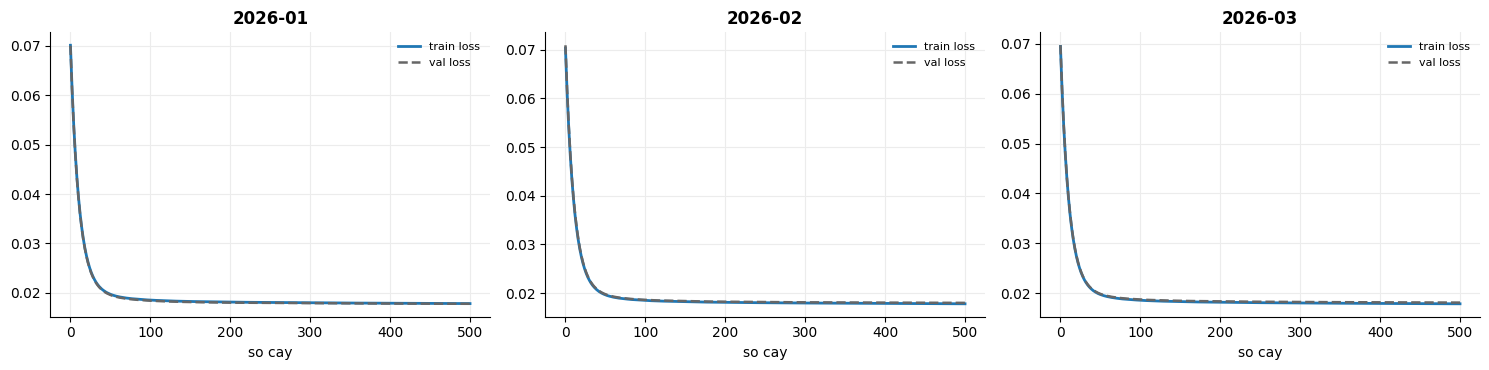

In [4]:
fig, axes = plt.subplots(1, len(thangs), figsize=(5*len(thangs), 3.8))
if len(thangs)==1: axes=[axes]
for ax, th in zip(axes, thangs):
    m=models[th]
    ax.plot(-np.array(m.train_score_), label="train loss", lw=2)
    ax.plot(-np.array(m.validation_score_), label="val loss", ls="--", lw=1.8, color="#666")
    ax.set_title(f"{th}", fontweight="bold"); ax.set_xlabel("so cay"); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

**4. Kết quả huấn luyện**

Gộp dự đoán test của cả 3 tháng, tính chỉ số: MAE, RMSE, R2, MAPE (VND).

In [5]:
allte = pd.concat(tests.values())
def metrics(y,p):
    y,p=np.asarray(y),np.asarray(p)
    return dict(MAE=mean_absolute_error(y,p), RMSE=mean_squared_error(y,p)**.5,
                R2=r2_score(y,p), MAPE=np.mean(np.abs((y-p)/y))*100)
rows=[]
for th in thangs:
    te=tests[th]; mk=metrics(te[TARGET],te.pred); rows.append({"thang":th,"n":len(te),**mk})
mk_all=metrics(allte[TARGET],allte.pred); rows.append({"thang":"TAT CA","n":len(allte),**mk_all})
bang=pd.DataFrame(rows).round(2)
print("KET QUA MODEL GIA (VND):"); display(bang)

KET QUA MODEL GIA (VND):


,thang,n,MAE,RMSE,R2,MAPE
0,2026-01,315360,18620.02,25331.14,0.71,15.44
1,2026-02,234632,18703.17,25425.64,0.71,15.34
2,2026-03,314368,19144.12,26119.83,0.70,15.29
3,TAT CA,864360,18833.21,25646.19,0.70,15.36


**5. Đánh giá**

So với baseline **persistence** (lấy y hệt quan sát gần nhất: `persistence_prediction`) — mốc bắt buộc phải vượt.
Thêm: phân bố sai số, dự đoán vs thực tế, sai số theo độ trễ.

MAE model      = 18,833 VND
MAE persistence= 33,683 VND (persistence_prediction)
Cai thien      = +44.1%


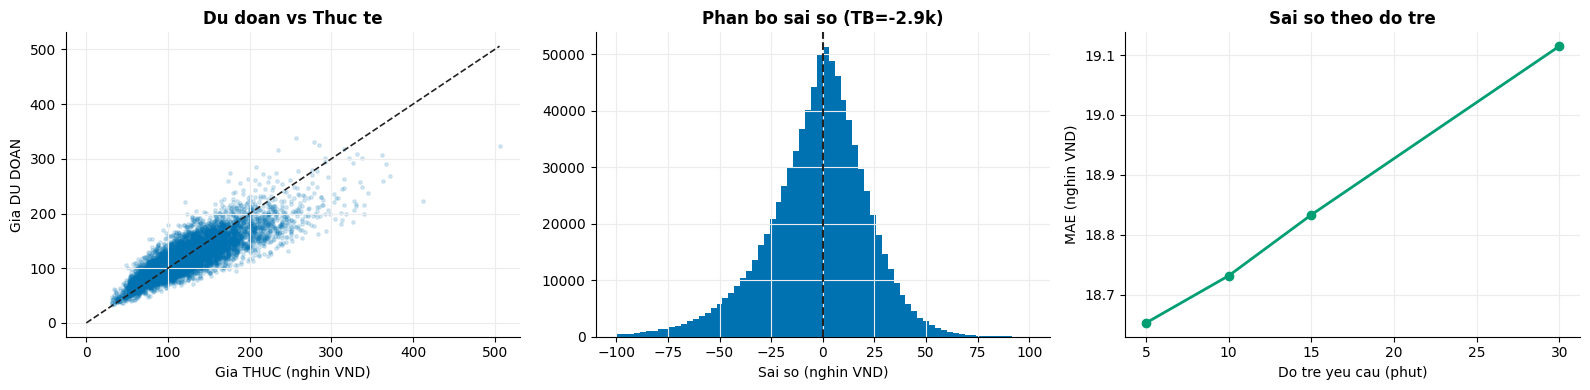

In [6]:
# vs baseline persistence
per = mean_absolute_error(allte[TARGET], allte["persistence_prediction"])
mae = mean_absolute_error(allte[TARGET], allte.pred)
print(f"MAE model      = {mae:,.0f} VND")
print(f"MAE persistence= {per:,.0f} VND (persistence_prediction)")
print(f"Cai thien      = {(1-mae/per)*100:+.1f}%")

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
s=allte.sample(min(8000,len(allte)), random_state=0)
ax[0].scatter(s[TARGET]/1000, s.pred/1000, s=6, alpha=.15, color="#0072B2")
lim=[0, s[TARGET].max()/1000]; ax[0].plot(lim,lim,"--",color="#222",lw=1.2)
ax[0].set_xlabel("Gia THUC (nghin VND)"); ax[0].set_ylabel("Gia DU DOAN"); ax[0].set_title("Du doan vs Thuc te", fontweight="bold")
err=(allte.pred-allte[TARGET])/1000
ax[1].hist(err, bins=70, range=(-100,100), color="#0072B2"); ax[1].axvline(0,color="#222",ls="--")
ax[1].set_xlabel("Sai so (nghin VND)"); ax[1].set_title(f"Phan bo sai so (TB={err.mean():+.1f}k)", fontweight="bold")
lagmae=allte.assign(ae=(allte.pred-allte[TARGET]).abs()).groupby("requested_lag_minutes").ae.mean()/1000
ax[2].plot(lagmae.index, lagmae.values, marker="o", lw=2, color="#009E73")
ax[2].set_xlabel("Do tre yeu cau (phut)"); ax[2].set_ylabel("MAE (nghin VND)"); ax[2].set_title("Sai so theo do tre", fontweight="bold")
plt.tight_layout(); plt.show()

**Lưu model**

In [ ]:
joblib.dump(models, "model_gia.joblib")
json.dump({"target":TARGET,"features":FEATS,"metrics":bang.to_dict("records")},
          open("ketqua_gia.json","w",encoding="utf-8"), ensure_ascii=False, indent=2, default=float)
print("Da luu model + ket qua.")

Da luu model + ket qua.


: 

**Kết luận**

Model GIÁ train theo từng tháng, đánh giá trên test chưa từng thấy. Vượt baseline persistence → có giá trị.

Bước tiếp theo: Uncertainty Quantification (Conformal Prediction) dùng tập `calibration` để xuất khoảng dự đoán.